In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

DATA_PATH = "../data/raw/ethiopia_fi_unified_data.csv"
df = pd.read_csv(DATA_PATH)
df["observation_date"] = pd.to_datetime(df["observation_date"], errors="coerce")
df["value_numeric"] = pd.to_numeric(df["value_numeric"], errors="coerce")
df["fiscal_year_num"] = df["fiscal_year"].astype(str).str.extract(r"(\d{4})").astype(float)

obs = df[df["record_type"] == "observation"].copy()
events = df[df["record_type"] == "event"].copy()
links = df[df["record_type"] == "impact_link"].copy()
targets = df[df["record_type"] == "target"].copy()

print(f"observations={len(obs)}, events={len(events)}, impact_links={len(links)}, targets={len(targets)}")

observations=32, events=11, impact_links=16, targets=3


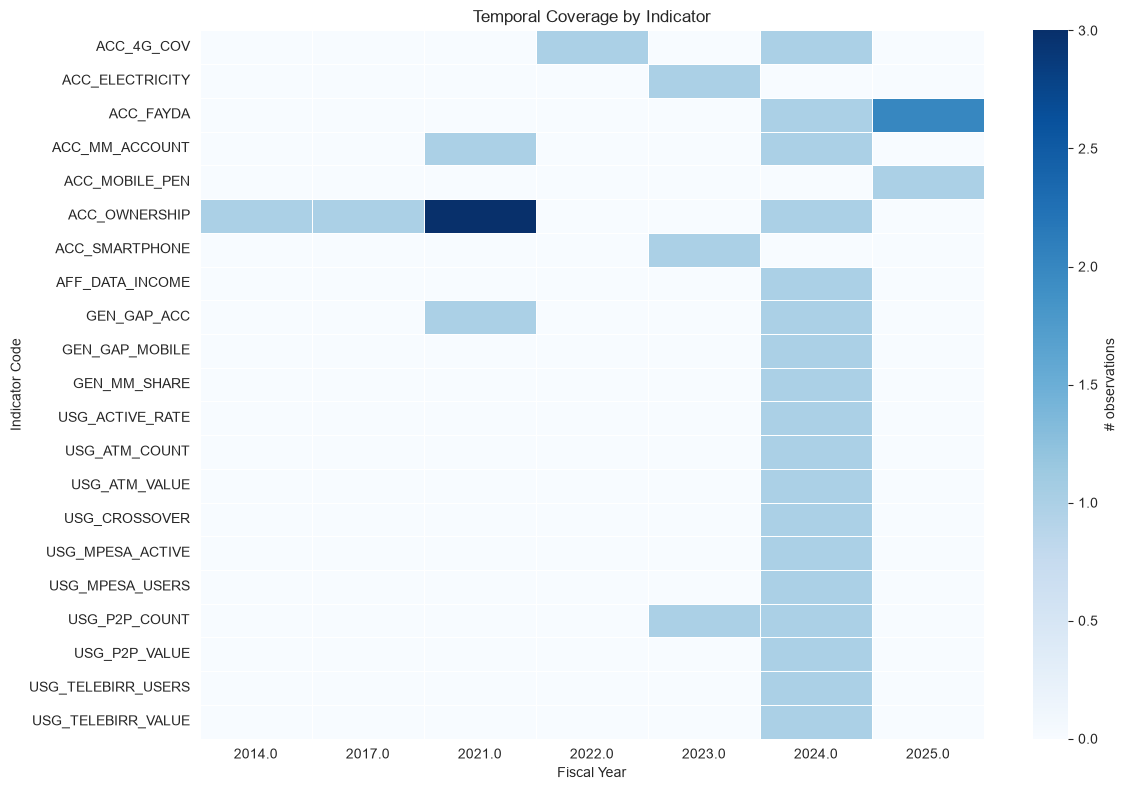

In [2]:
coverage = obs.pivot_table(index="indicator_code", columns="fiscal_year_num",
                            values="record_id", aggfunc="count", fill_value=0)
plt.figure(figsize=(12, 8))
sns.heatmap(coverage, cmap="Blues", cbar_kws={"label": "# observations"}, linewidths=0.5)
plt.title("Temporal Coverage by Indicator")
plt.xlabel("Fiscal Year")
plt.ylabel("Indicator Code")
plt.tight_layout()
plt.show()

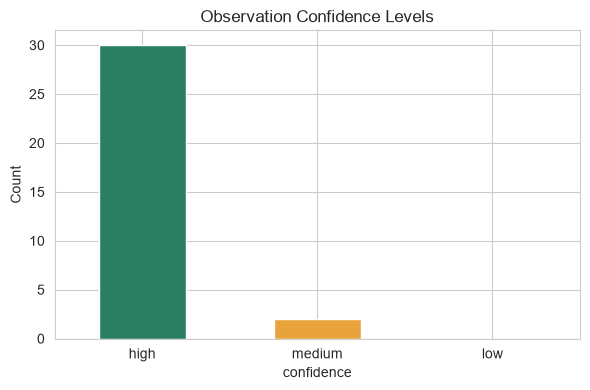

confidence
high      30.0
medium     2.0
low        0.0
Name: count, dtype: float64


In [3]:
conf_order = ["high", "medium", "low"]
conf_counts = obs["confidence"].value_counts().reindex(conf_order).fillna(0)
plt.figure(figsize=(6, 4))
conf_counts.plot(kind="bar", color=["#2a7f62", "#e8a33d", "#c94c4c"])
plt.title("Observation Confidence Levels")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(conf_counts)

In [4]:
sparse = (obs.groupby("indicator_code")
             .agg(indicator=("indicator", "first"), pillar=("pillar", "first"),
                  n_obs=("record_id", "count"))
             .sort_values("n_obs"))
print("Indicators with only 1 observation (sparsest):")
print(sparse[sparse["n_obs"] == 1])

Indicators with only 1 observation (sparsest):
                                            indicator         pillar  n_obs
indicator_code                                                             
ACC_ELECTRICITY               Electricity Access Rate         ACCESS      1
AFF_DATA_INCOME              Data Affordability Index  AFFORDABILITY      1
ACC_SMARTPHONE               Smartphone Adoption Rate         ACCESS      1
ACC_MOBILE_PEN        Mobile Subscription Penetration         ACCESS      1
USG_ATM_COUNT                   ATM Transaction Count          USAGE      1
USG_ACTIVE_RATE            Mobile Money Activity Rate          USAGE      1
GEN_MM_SHARE        Female Mobile Money Account Share         GENDER      1
GEN_GAP_MOBILE                Mobile Phone Gender Gap         GENDER      1
USG_CROSSOVER                 P2P/ATM Crossover Ratio          USAGE      1
USG_ATM_VALUE                   ATM Transaction Value          USAGE      1
USG_MPESA_ACTIVE           M-Pesa 90-Day 

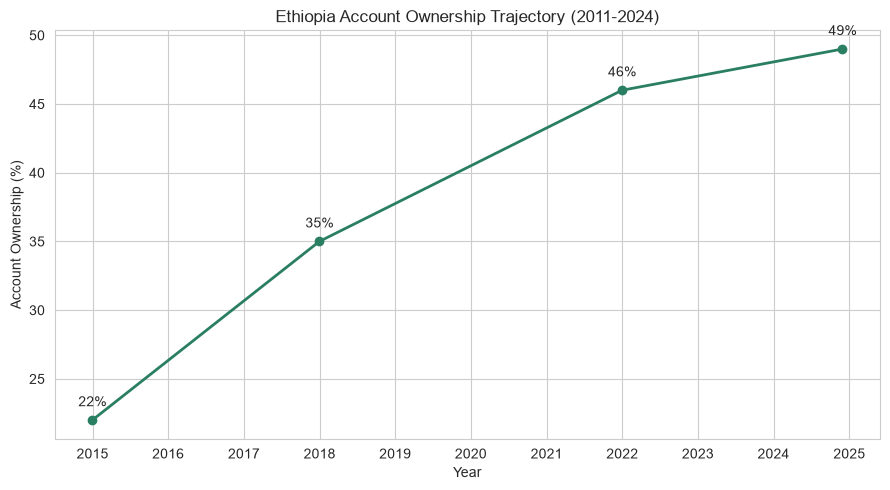

,observation_date,value_numeric,source_name
0,2014-12-31,22.0,Global Findex 2014
1,2017-12-31,35.0,Global Findex 2017
2,2021-12-31,46.0,Global Findex 2021
5,2024-11-29,49.0,Global Findex 2024


In [5]:
access = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["gender"] == "all")].sort_values("observation_date")
plt.figure(figsize=(9, 5))
plt.plot(access["observation_date"], access["value_numeric"], marker="o", linewidth=2, color="#2a7f62")
for _, row in access.iterrows():
    plt.annotate(f"{row['value_numeric']:.0f}%", (row["observation_date"], row["value_numeric"]),
                 textcoords="offset points", xytext=(0, 10), ha="center")
plt.title("Ethiopia Account Ownership Trajectory (2011-2024)")
plt.ylabel("Account Ownership (%)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()
access[["observation_date", "value_numeric", "source_name"]]

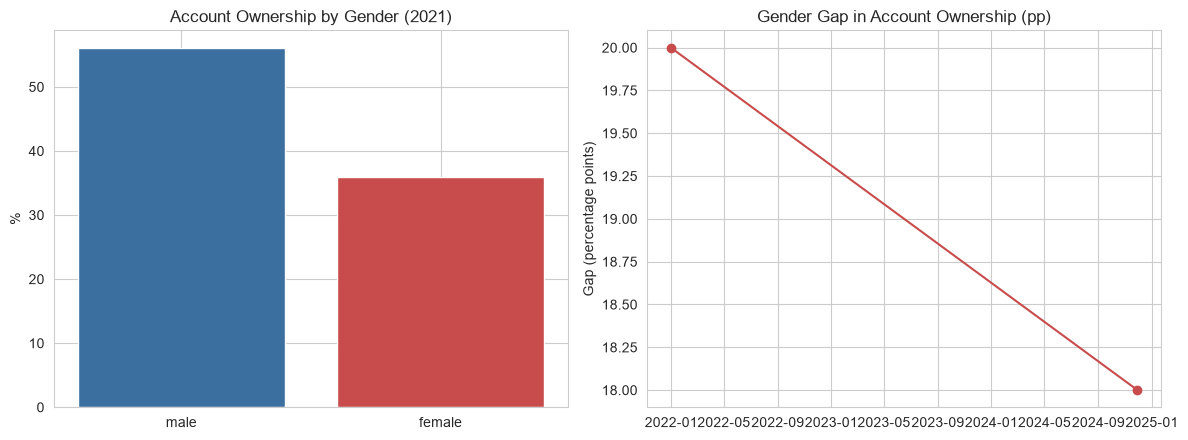

Gender gap narrowed from 20.0 pp (2021) to 18.0 pp (2024, estimated - confidence:medium)


In [6]:
gender_2021 = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["gender"].isin(["male", "female"]))]
gap_trend = obs[obs["indicator_code"] == "GEN_GAP_ACC"].sort_values("observation_date")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(gender_2021["gender"], gender_2021["value_numeric"], color=["#3b6fa0", "#c94c4c"])
axes[0].set_title("Account Ownership by Gender (2021)")
axes[0].set_ylabel("%")
axes[1].plot(gap_trend["observation_date"], gap_trend["value_numeric"], marker="o", color="#c94c4c")
axes[1].set_title("Gender Gap in Account Ownership (pp)")
axes[1].set_ylabel("Gap (percentage points)")
plt.tight_layout()
plt.show()
print("Gender gap narrowed from", gap_trend["value_numeric"].iloc[0], "pp (2021) to",
      gap_trend["value_numeric"].iloc[-1], "pp (2024, estimated - confidence:medium)")

In [7]:
urban_rural = obs[obs["location"].isin(["urban", "rural"])]
if urban_rural.empty:
    print("DATA GAP: No urban/rural disaggregated observations exist in the dataset.")
    print("The only urban/rural split available is indirect: electricity access")
    print("(urban 94.7% vs rural 43.6%, World Bank 2023) - a plausible proxy/enabler,")
    print("not a direct account-ownership split. Flagged in data_enrichment_log.md.")
else:
    print(urban_rural)

DATA GAP: No urban/rural disaggregated observations exist in the dataset.
The only urban/rural split available is indirect: electricity access
(urban 94.7% vs rural 43.6%, World Bank 2023) - a plausible proxy/enabler,
not a direct account-ownership split. Flagged in data_enrichment_log.md.


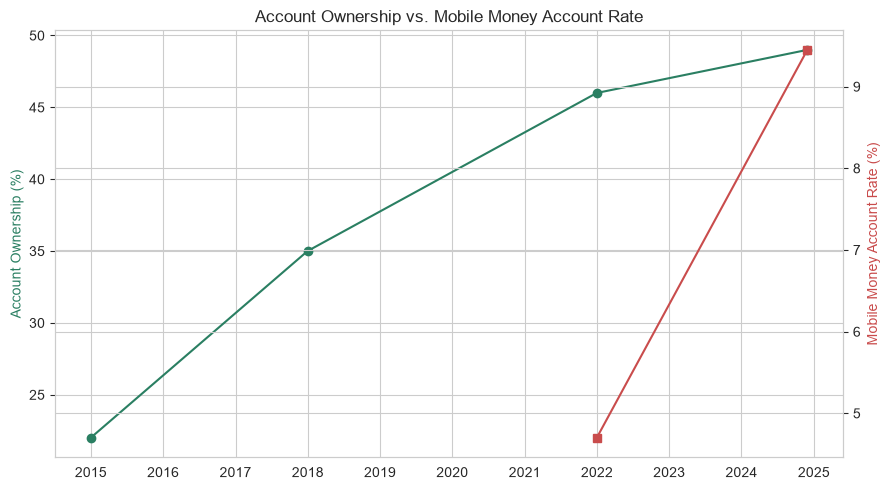

Account ownership grew +3pp (2021-2024) while
Mobile money account rate grew +4.75pp (~doubled) in the same window.
This confirms the brief's framing: massive mobile-money growth did not translate
proportionally into overall account ownership gains - see Sheet D 'Mobile-Money-Only
Users Are Extremely Rare' (~0.5% of adults) as a likely explanation: most new mobile
money accounts in Ethiopia are opened by people who already have a bank account,
so mobile money growth is substituting/complementing existing access more than
creating new first-time account holders.


In [8]:
mm = obs[(obs["indicator_code"] == "ACC_MM_ACCOUNT") & (obs["gender"] == "all")].sort_values("observation_date")

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(access["observation_date"], access["value_numeric"], marker="o", color="#2a7f62", label="Account Ownership (%)")
ax1.set_ylabel("Account Ownership (%)", color="#2a7f62")
ax2 = ax1.twinx()
ax2.plot(mm["observation_date"], mm["value_numeric"], marker="s", color="#c94c4c", label="Mobile Money Account Rate (%)")
ax2.set_ylabel("Mobile Money Account Rate (%)", color="#c94c4c")
plt.title("Account Ownership vs. Mobile Money Account Rate")
fig.tight_layout()
plt.show()

acc_growth_21_24 = access[access["observation_date"].dt.year == 2024]["value_numeric"].iloc[0] - \
                   access[access["observation_date"].dt.year == 2021]["value_numeric"].iloc[0]
mm_growth_21_24 = mm[mm["observation_date"].dt.year == 2024]["value_numeric"].iloc[0] - \
                  mm[mm["observation_date"].dt.year == 2021]["value_numeric"].iloc[0]
print(f"Account ownership grew +{acc_growth_21_24:.0f}pp (2021-2024) while")
print(f"Mobile money account rate grew +{mm_growth_21_24:.2f}pp (~doubled) in the same window.")
print("This confirms the brief's framing: massive mobile-money growth did not translate")
print("proportionally into overall account ownership gains - see Sheet D 'Mobile-Money-Only")
print("Users Are Extremely Rare' (~0.5% of adults) as a likely explanation: most new mobile")
print("money accounts in Ethiopia are opened by people who already have a bank account,")
print("so mobile money growth is substituting/complementing existing access more than")
print("creating new first-time account holders.")